<a href="https://colab.research.google.com/github/zaraaa12/BigData/blob/main/Visualisasi_Macbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import when
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    Tokenizer, StopWordsRemover, CountVectorizer, IDF,
    StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
)
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [2]:
# Inisialisasi SparkSession
spark = SparkSession.builder \
    .appName("ShopeeProductClassification") \
    .getOrCreate()

# Load data CSV
df = spark.read.csv("/content/macbook_cleaned_full.csv", header=True, inferSchema=True)

#tampilkan data
df.show(10)


+------+---------------+----+--------+--------------------+--------------------+
|Rating|       Location|Sold|   Price|                URLs|        Product_Name|
+------+---------------+----+--------+--------------------+--------------------+
|   4.9|  Jakarta Pusat| 654|10488000|https://shopee.co...|"MacBook M1 | Mac...|
|   5.0|       Semarang|   2| 8703000|https://shopee.co...|Macbook Air 13 M1...|
|   5.0|        Bandung|   5|10699000|https://shopee.co...|"Macbook Air M1 8...|
|   5.0|    Kab. Sleman|   1|10699000|https://shopee.co...|Macbook Air M1 8/...|
|   5.0|  Jakarta Timur|   1| 9000000|https://shopee.co...|[PRELOVED] MacBoo...|
|   5.0|       Surabaya|  64| 6000000|https://shopee.co...|Macbook Pro M1 Ch...|
|   5.0|Jakarta Selatan|  10|23499000|https://shopee.co...|Macbook Air 15 in...|
|   5.0|  Jakarta Utara| 393|10654000|https://shopee.co...|IBOX APPLE MACBOO...|
|   5.0|          Depok|  15| 8940000|https://shopee.co...|MacBook Air M1 Ch...|
|   5.0|        Bandung|  10

In [3]:
# 1. Buat label klasifikasi berdasarkan kolom terjual
df = df.withColumn(
    "label",
    when(df.Sold < 100, 0) \
    .when((df.Sold >= 100) & (df.Sold < 1000), 1) \
    .otherwise(2)
)

In [4]:
# 2. Transform Judul
tokenizer = Tokenizer(inputCol="Product_Name", outputCol="words")
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
vectorizer = CountVectorizer(inputCol="filtered_words", outputCol="rawFeatures")
idf = IDF(inputCol="rawFeatures", outputCol="title_features")

In [5]:
# 3. Transform Lokasi
tempat_indexer = StringIndexer(inputCol="Location", outputCol="location_index", handleInvalid="keep")
tempat_encoder = OneHotEncoder(inputCol="location_index", outputCol="location_encoded")

In [6]:
# 4. Scaling fitur harga
harga_assembler = VectorAssembler(inputCols=["Price"], outputCol="price_vec")
harga_scaler = StandardScaler(inputCol="price_vec", outputCol="price_scaled")

In [7]:
# 5. Gabungkan semua fitur menjadi vector features
feature_assembler = VectorAssembler(
    inputCols=["title_features", "location_encoded", "price_scaled"],
    outputCol="features"
)

In [8]:
# 6. Definisikan model klasifikasi RandomForest
classifier = RandomForestClassifier(featuresCol="features", labelCol="label", seed=42)

In [9]:
# 7. Buat pipeline lengkap
pipeline = Pipeline(stages=[
    tokenizer,
    remover,
    vectorizer,
    idf,
    tempat_indexer,
    tempat_encoder,
    harga_assembler,
    harga_scaler,
    feature_assembler,
    classifier
])

In [10]:
# 8. Bagi data train-test split
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

# 9. Latih model
model = pipeline.fit(train_df)

# 10. Prediksi di data test
predictions = model.transform(test_df)

In [11]:
# 11. Evaluasi akurasi
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9411764705882353


In [12]:
# 12. Classification

# Tambahkan kolom label_name
predictions = predictions.withColumn(
    "label_name",
    when(predictions.label == 0, "Low") \
    .when(predictions.label == 1, "Medium") \
    .otherwise("High")
)

# (Opsional) Tambahkan juga prediksi label_name
predictions = predictions.withColumn(
    "predicted_label_name",
    when(predictions.prediction == 0, "Low") \
    .when(predictions.prediction == 1, "Medium") \
    .otherwise("High")
)

predictions.select("Product_Name", "Price", "Sold","Location", "label_name", "prediction").show(100)

+--------------------+--------+----+---------------+----------+----------+
|        Product_Name|   Price|Sold|       Location|label_name|prediction|
+--------------------+--------+----+---------------+----------+----------+
|Apple MacBook Air...|12499000|  14|         Bekasi|       Low|       0.0|
|macbook air retin...| 7900000|  40|  Jakarta Pusat|       Low|       0.0|
|MACBOOK AIR M1 8/...| 8999000|   8|Jakarta Selatan|       Low|       0.0|
|MacBook Air M2 20...|14191000|  55|  Jakarta Pusat|       Low|       0.0|
|Macbook Air M1 20...| 6390000| 276|Jakarta Selatan|    Medium|       0.0|
|MACBOOK AIR 2020 ...|11232900|  17|       Makassar|       Low|       0.0|
|MacBook Pro 2020 ...| 8950000|  10|        Bandung|       Low|       0.0|
|OBRALL LAPTOP MAC...|12300000|   2|  Jakarta Barat|       Low|       0.0|
|"MacBook Pro 2021...|21999000|   1|Jakarta Selatan|       Low|       0.0|
|Apple Macbook Air...| 8700000|   5|Jakarta Selatan|       Low|       0.0|
|MacBook Air M1 20...|106

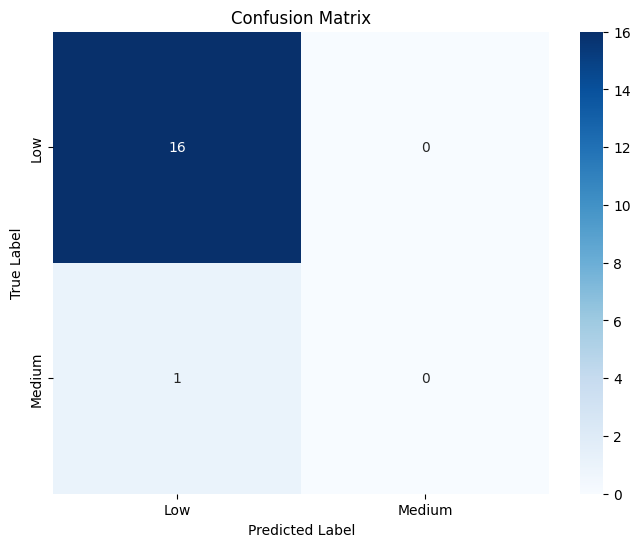

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Konversi DataFrame PySpark ke Pandas
# Pilih kolom yang relevan untuk confusion matrix
pandas_df = predictions.select("label_name", "prediction").toPandas()

# Konversi kolom 'prediction' menjadi string agar sesuai dengan tipe data 'label_name'
# Gunakan mapping yang sama seperti saat membuat 'predicted_label_name'
pandas_df['prediction'] = pandas_df['prediction'].apply(
    lambda x: 'Low' if x == 0 else ('Medium' if x == 1 else 'High')
)


# Confusion Matrix
# Gunakan string labels untuk kedua argumen
cm = confusion_matrix(pandas_df['label_name'], pandas_df['prediction'])
# Dapatkan unique labels dari kolom string
labels = sorted(pandas_df['label_name'].unique())

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
# Pastikan order label di heatmap sama dengan order di confusion matrix
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

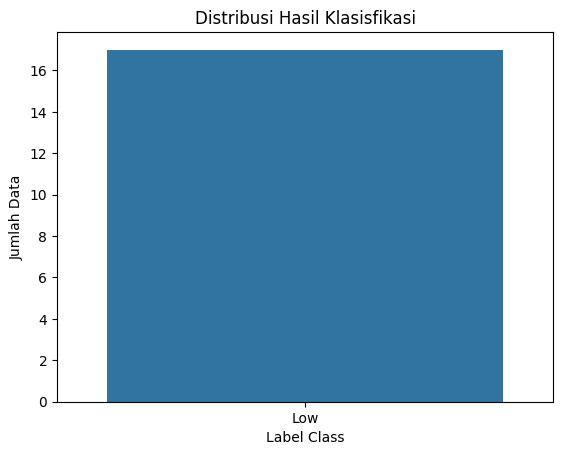

In [14]:
sns.countplot(x="prediction", data=pandas_df)
plt.title("Distribusi Hasil Klasisfikasi")
plt.xlabel("Label Class")
plt.ylabel("Jumlah Data")
plt.show()

In [15]:
save = predictions.select("Product_Name", "Price", "Sold","Location", "label_name", "prediction")
save.write.csv('/content/mac_predictions', header=True, mode='overwrite')

In [27]:
import pandas as pd

df = pd.read_csv('mac_prediction.csv')
df.head()

,Product_Name,Price,Sold,Location,label_name,prediction
0,Apple MacBook Air M1 2020 SSD Cepat 18 Jam Bat...,12499000,14,Bekasi,Low,0.0
1,macbook air retina 2020 chip set m1 Ram 8 GB S...,7900000,40,Jakarta Pusat,Low,0.0
2,MACBOOK AIR M1 8/256GB SECOND,8999000,8,Jakarta Selatan,Low,0.0
3,MacBook Air M2 2022 13 Inch 256GB/512GB Bergar...,14191000,55,Jakarta Pusat,Low,0.0
4,Macbook Air M1 2020 Ram 8Gb Ssd 256Gb Kondisi ...,6390000,276,Jakarta Selatan,Medium,0.0


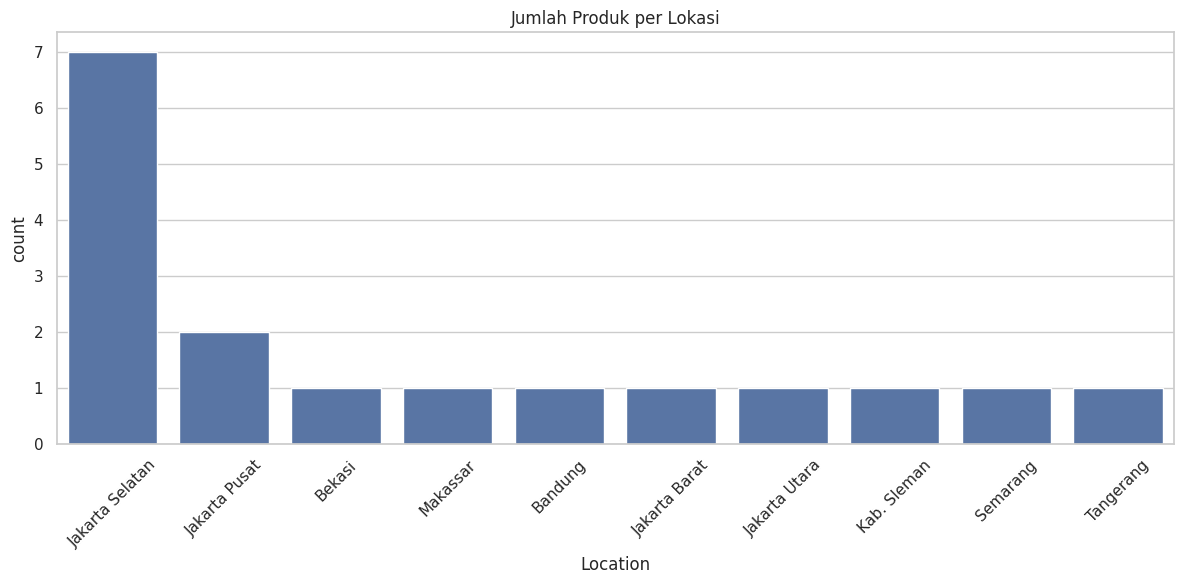

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Location', order=df['Location'].value_counts().index)
plt.title('Jumlah Produk per Lokasi')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


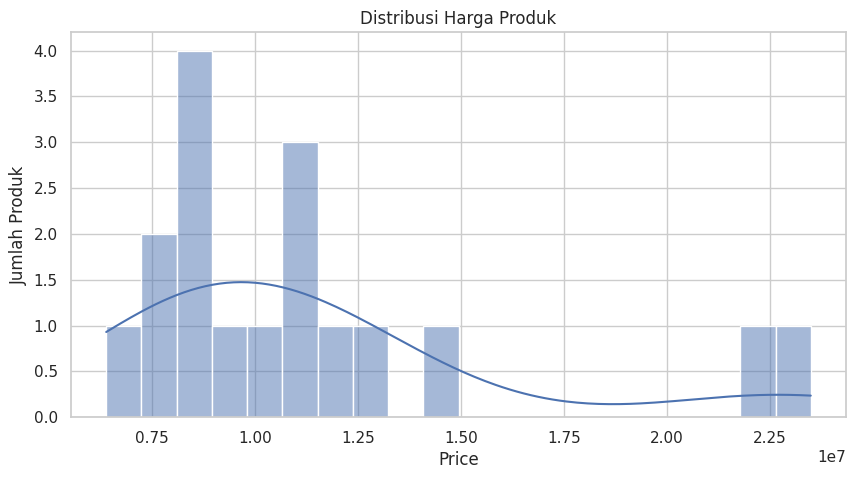

In [33]:
plt.figure(figsize=(10,5))
sns.histplot(df['Price'], bins=20, kde=True)
plt.title('Distribusi Harga Produk')
plt.xlabel('Price')
plt.ylabel('Jumlah Produk')
plt.show()

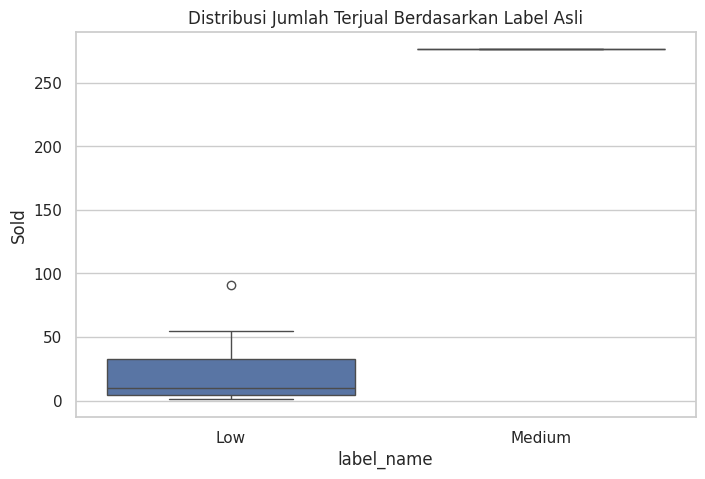

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='label_name', y='Sold')
plt.title('Distribusi Jumlah Terjual Berdasarkan Label Asli')
plt.show()

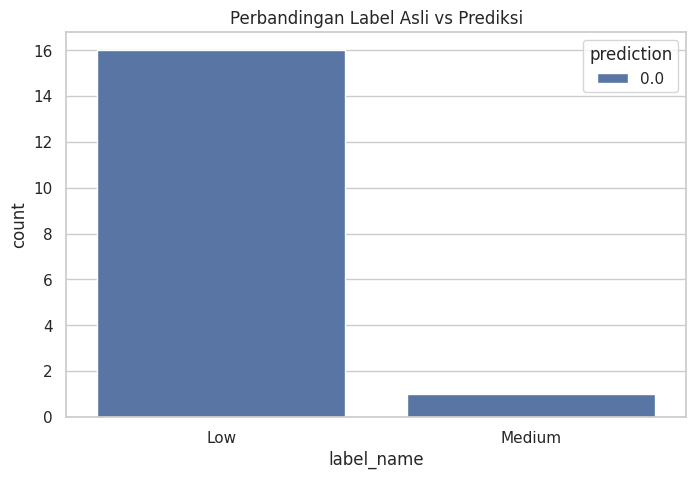

In [35]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='label_name', hue='prediction')
plt.title('Perbandingan Label Asli vs Prediksi')
plt.show()